# Capstone project 
##### The problem: A bank loses money every time a customer closes their account (Exited). Acquiring a new customer costs far more than retaining an existing one — so the bank wants to predict which customers are at risk of leaving, before they leave, so the retention team can proactively intervene (better rates, personalized outreach, etc.)

# Import libabries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix








print(os.getcwd())

c:\Users\Edward\daily-ds\deep-learning


# Load data 

In [2]:
df = pd.read_csv('../ml/data/Bank Customer Churn Prediction.csv')
print(df.info())
print(df.describe())

# check for any na or empty rows
#df.isnull().sum()
#df.isna().sum()
# no empty or na rows

df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB
None
        customer_id  credit_score           age        tenure        balance  \
count  1.000000e+04  10000.000000  10000.000000  10000.000000   10000.000000   
mean 

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


# EDA

### Inspect Churn distribution 

Number of customers who churned: 2037
NUmber of customers who did not churned: 7963
Churn rate: 20.37%


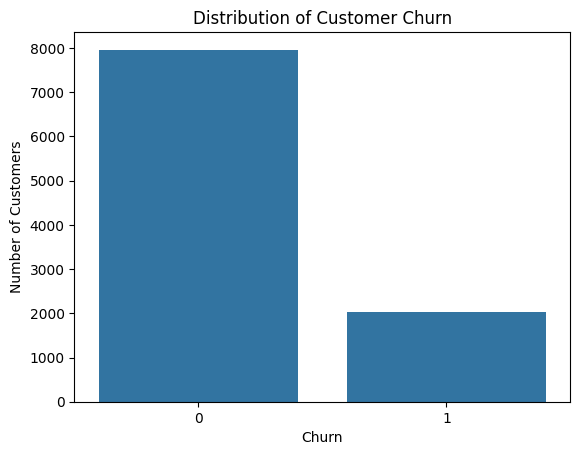

In [3]:
print(f"Number of customers who churned: {(df['churn']==1).sum()}")
print(f"NUmber of customers who did not churned: {(df['churn']==0).sum()}")
churn_rate = (df['churn'].sum()/len(df)) *100
print(f"Churn rate: {churn_rate:.2f}%")


sns.countplot(data = df, x="churn")
plt.title("Distribution of Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

### Gender vs Churn

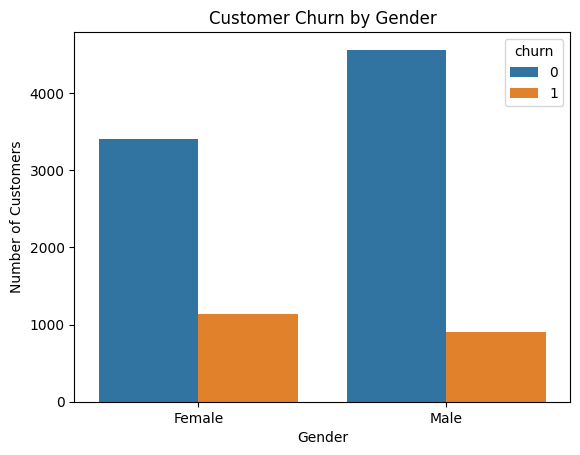

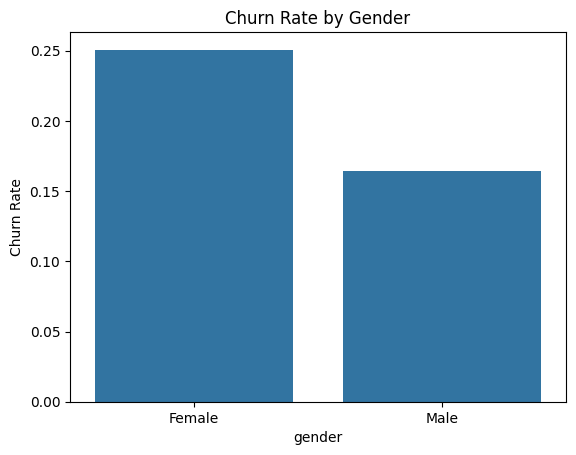

In [4]:
sns.countplot(
    data=df,
    x="gender",
    hue="churn"
)

plt.title("Customer Churn by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.show()

# churn rate per gender 
gender_churn = df.groupby("gender")["churn"].mean().reset_index()

sns.barplot(
    data=gender_churn,
    x="gender",
    y="churn"
)

plt.ylabel("Churn Rate")
plt.title("Churn Rate by Gender")
plt.show()

### Country vs Churn

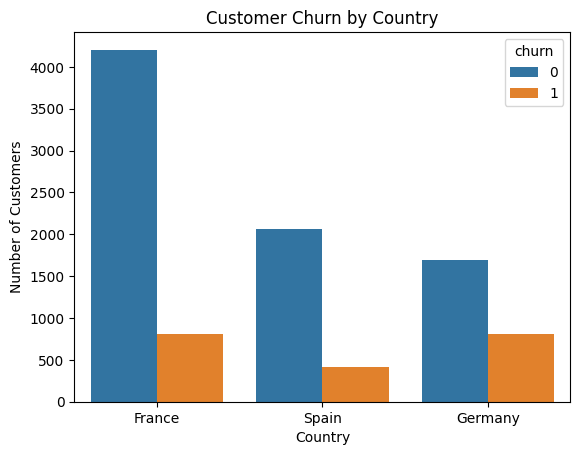

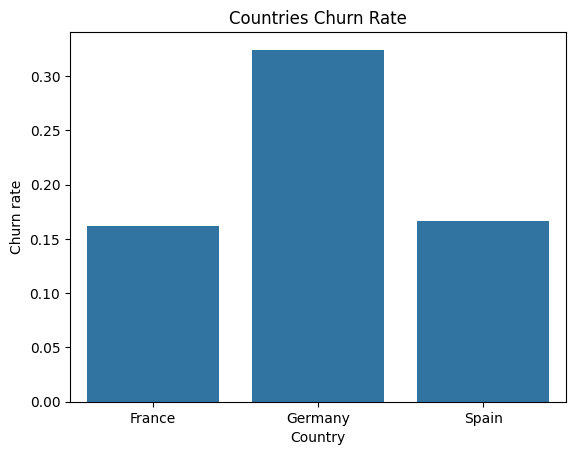

In [5]:
sns.countplot(
    data=df,
    x="country",
    hue="churn"
)

plt.title("Customer Churn by Country")
plt.xlabel("Country")
plt.ylabel("Number of Customers")
plt.show()

# similar to gender we can look at the each countrys avergae churn rate
country_churn = df.groupby('country')['churn'].mean().reset_index()
sns.barplot(data=country_churn, x='country', y='churn')
plt.title('Countries Churn Rate')
plt.xlabel('Country')
plt.ylabel('Churn rate')
plt.show()

### Active memeber vs Churn

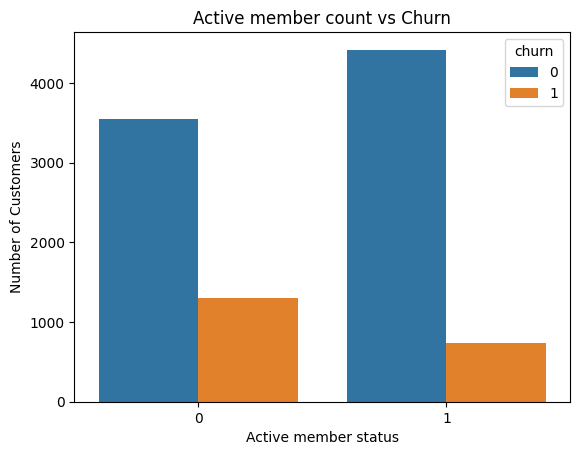

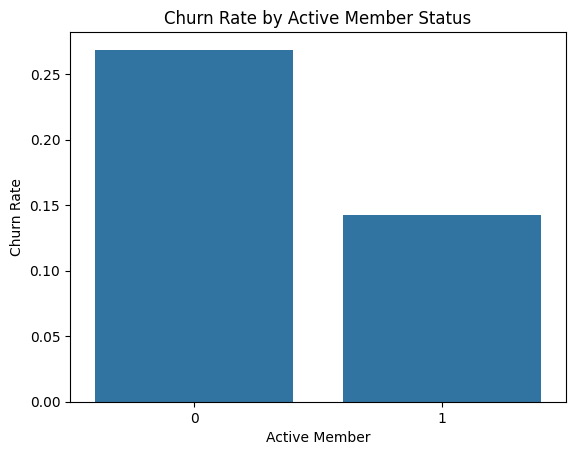

In [6]:
sns.countplot(data=df, x='active_member', hue='churn')
plt.title('Active member count vs Churn')
plt.xlabel('Active member status')
plt.ylabel('Number of Customers')
plt.show()

active_churn = df.groupby("active_member")["churn"].mean().reset_index()

sns.barplot(
    data=active_churn,
    x="active_member",
    y="churn"
)

plt.title("Churn Rate by Active Member Status")
plt.xlabel("Active Member")
plt.ylabel("Churn Rate")
plt.show()

### Number of Products vs Churn

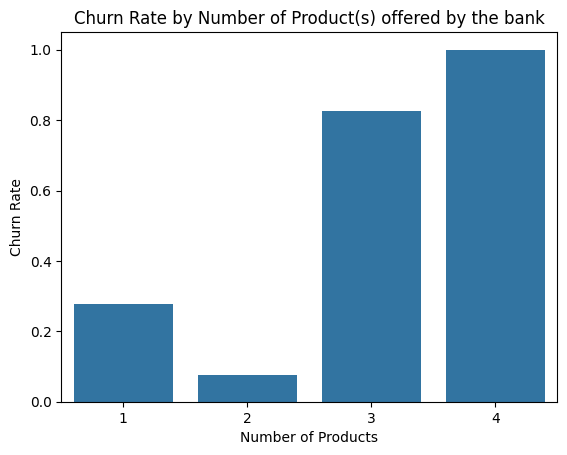

In [7]:
product_churn = df.groupby('products_number')['churn'].mean().reset_index()

sns.barplot(data=product_churn, x='products_number',y='churn')
plt.title('Churn Rate by Number of Product(s) offered by the bank')
plt.xlabel('Number of Products')
plt.ylabel('Churn Rate')
plt.show()

### Credit Score vs Churn

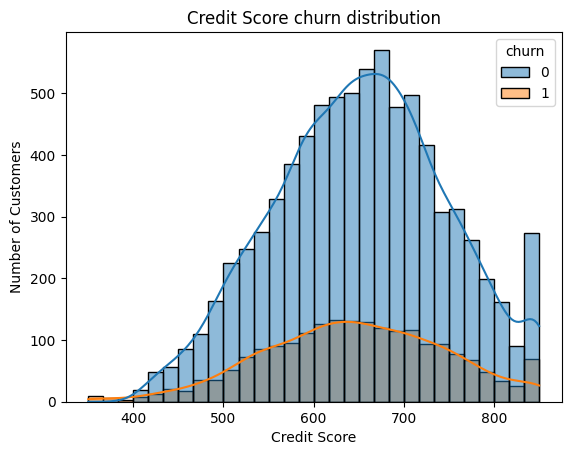

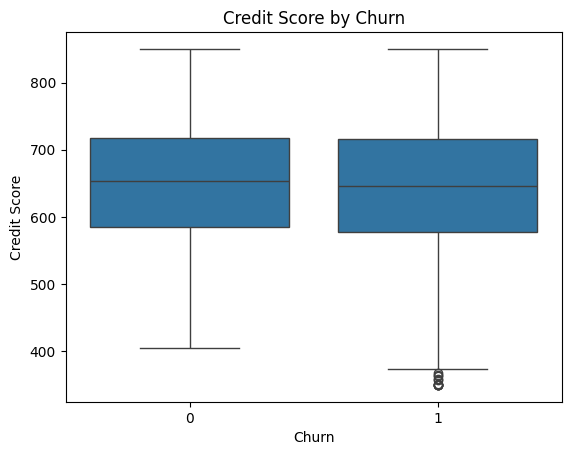

In [8]:
sns.histplot(data=df, x='credit_score', hue='churn', bins =30, kde= True)
plt.title('Credit Score churn distribution')
plt.xlabel('Credit Score')
plt.ylabel('Number of Customers')
plt.show()

sns.boxplot(
    data=df,
    x="churn",
    y="credit_score"
)

plt.title("Credit Score by Churn")
plt.xlabel("Churn")
plt.ylabel("Credit Score")
plt.show()

### Age vs Churn

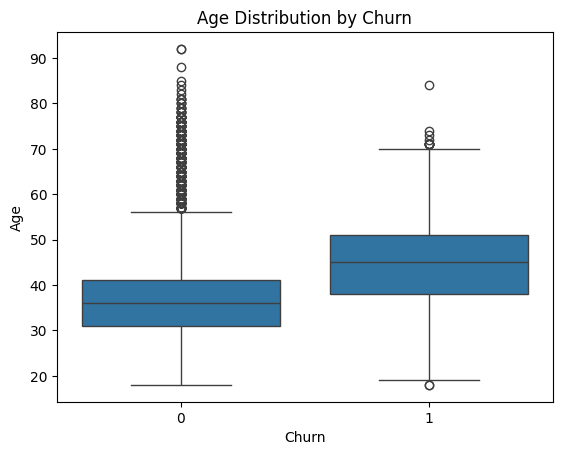

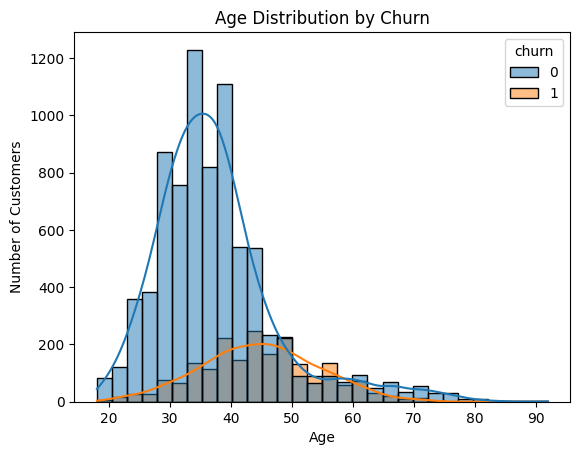

In [9]:
sns.boxplot(data=df, x="churn", y="age")

plt.title("Age Distribution by Churn")
plt.xlabel("Churn")
plt.ylabel("Age")
plt.show()

sns.histplot(
    data=df,
    x="age",
    hue="churn",
    bins=30,
    kde=True
)

plt.title("Age Distribution by Churn")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.show()

### Balance vs Churn

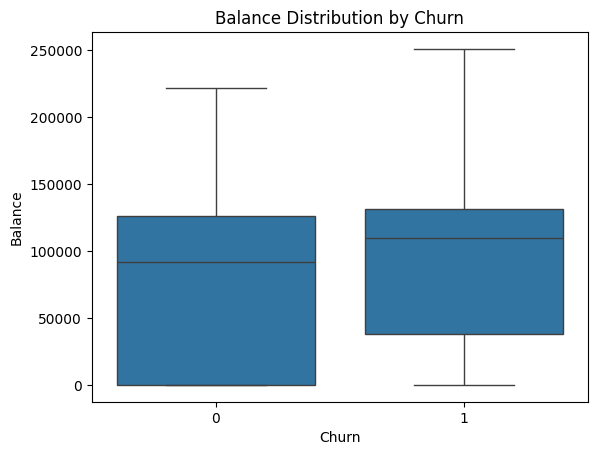

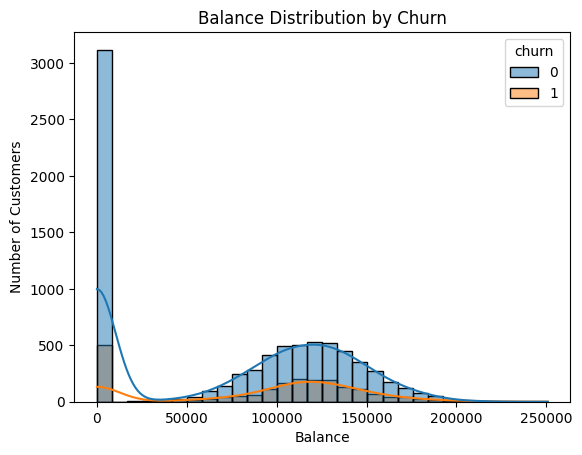

In [10]:
sns.boxplot(data=df, x="churn", y="balance")

plt.title("Balance Distribution by Churn")
plt.xlabel("Churn")
plt.ylabel("Balance")
plt.show()

sns.histplot(
    data=df,
    x="balance",
    hue="churn",
    bins=30,
    kde=True
)

plt.title("Balance Distribution by Churn")
plt.xlabel("Balance")
plt.ylabel("Number of Customers")
plt.show()

### Estimated Salary vs Churn

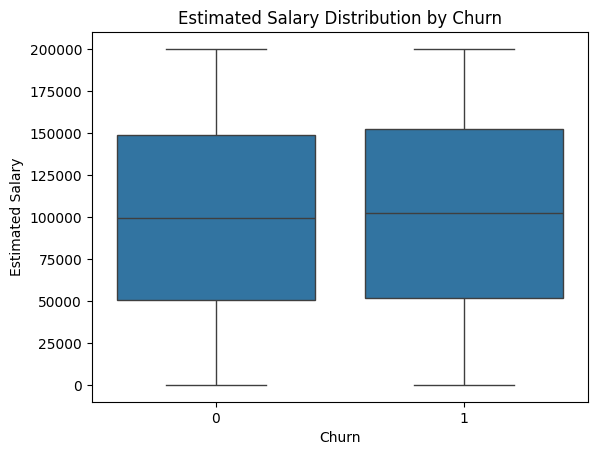

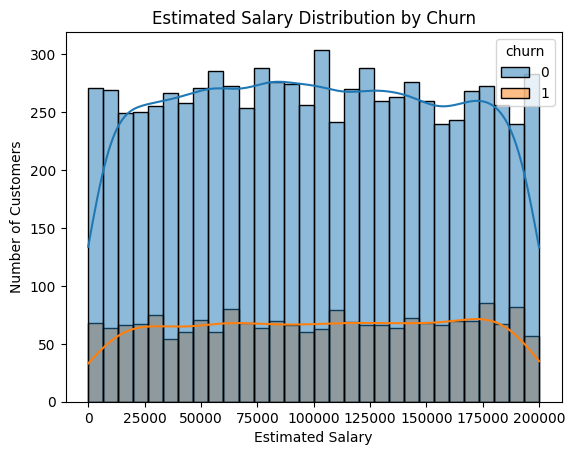

In [11]:
sns.boxplot(data=df, x="churn", y="estimated_salary")

plt.title("Estimated Salary Distribution by Churn")
plt.xlabel("Churn")
plt.ylabel("Estimated Salary")
plt.show()

sns.histplot(
    data=df,
    x="estimated_salary",
    hue="churn",
    bins=30,
    kde=True
)

plt.title("Estimated Salary Distribution by Churn")
plt.xlabel("Estimated Salary")
plt.ylabel("Number of Customers")
plt.show()

## Tenure vs Churn

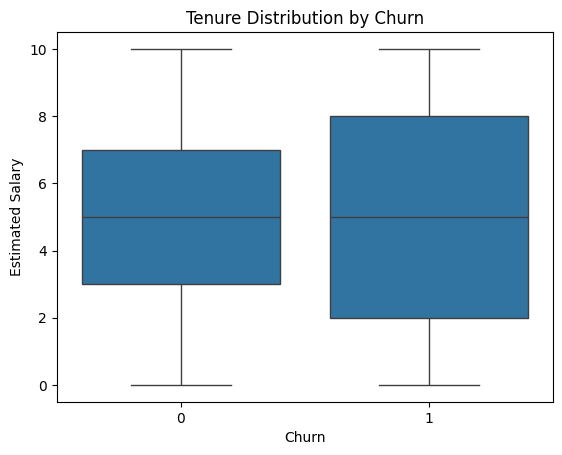

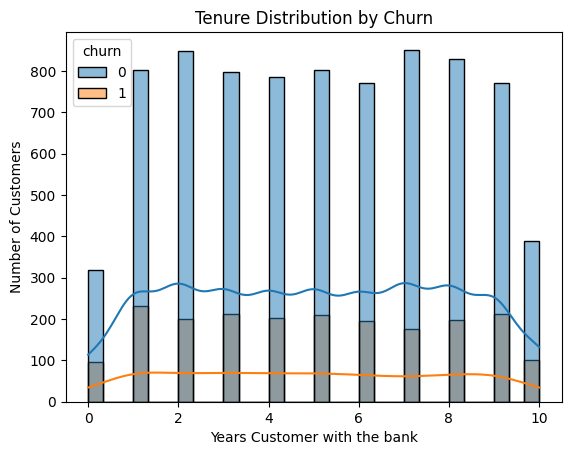

In [12]:
sns.boxplot(data=df, x="churn", y="tenure")

plt.title("Tenure Distribution by Churn")
plt.xlabel("Churn")
plt.ylabel("Estimated Salary")
plt.show()

sns.histplot(
    data=df,
    x="tenure",
    hue="churn",
    bins=30,
    kde=True
)

plt.title("Tenure Distribution by Churn")
plt.xlabel("Years Customer with the bank")
plt.ylabel("Number of Customers")
plt.show()

## Correlation Heat Map between each attributes

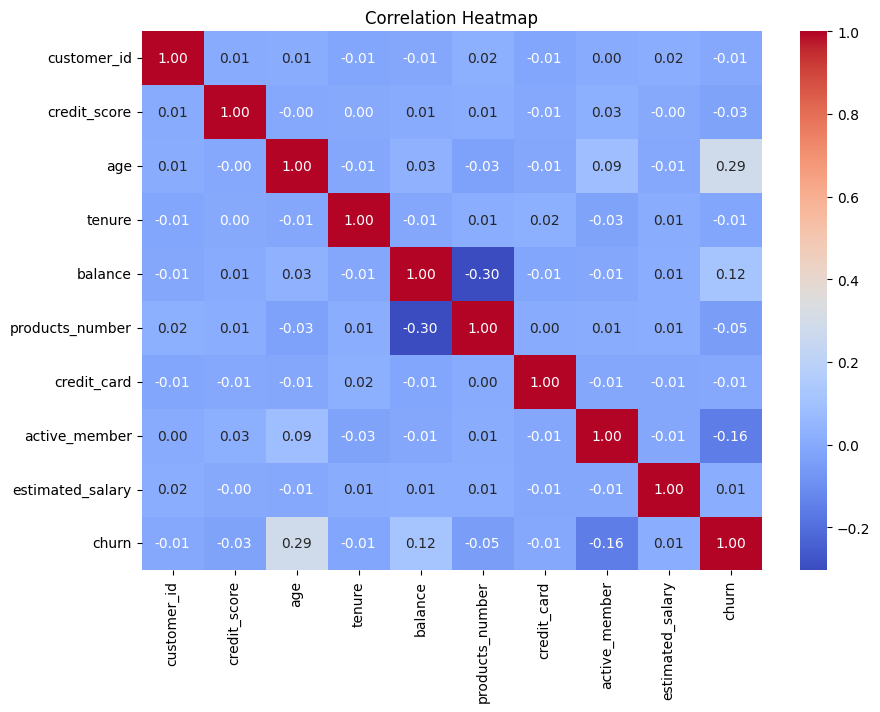

In [13]:
numeric_df = df.select_dtypes(include="number")

plt.figure(figsize=(10, 7))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

### Scattermatrix

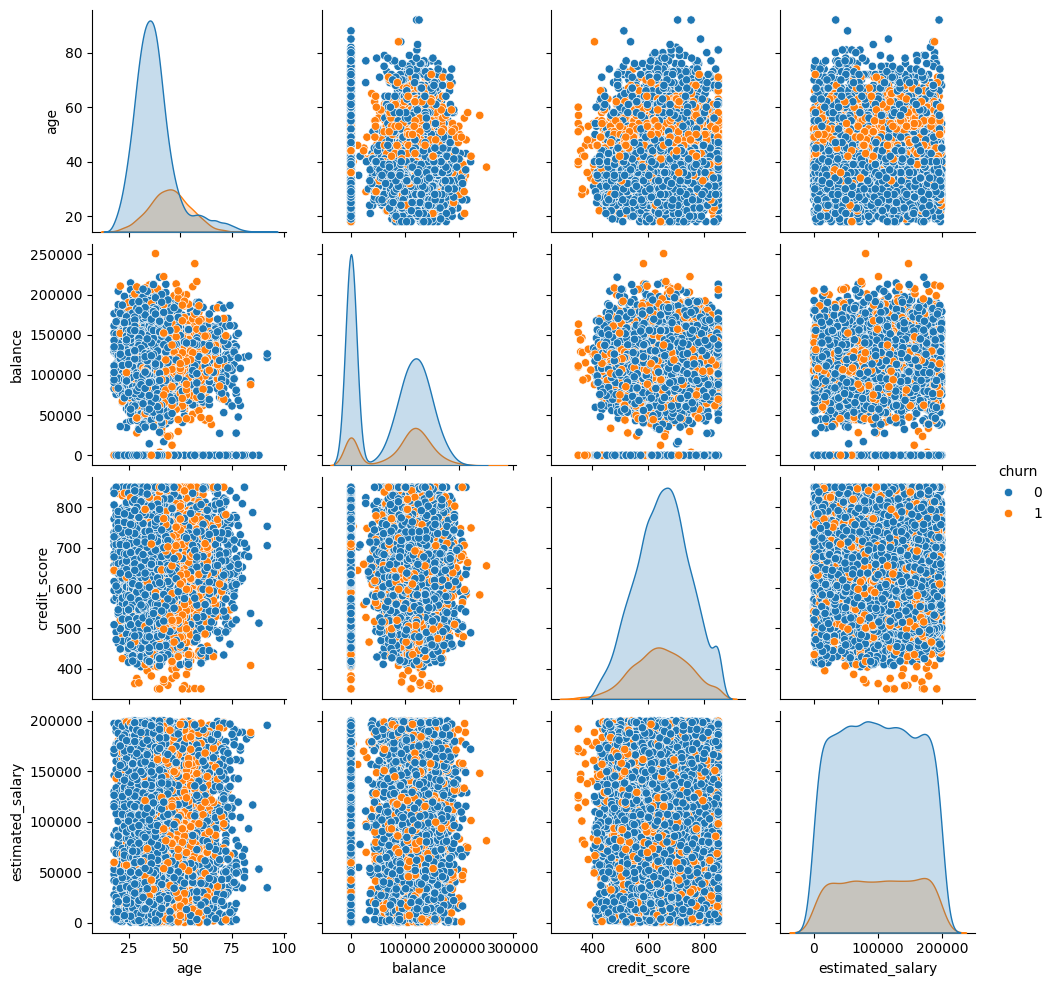

In [14]:
sns.pairplot(
    df,
    vars=["age", "balance", "credit_score", "estimated_salary"],
    hue="churn"
)

plt.show()

# Findings

#### We have an unbalanced data set with only ~20% churn rate. from catgorical attributes, we can see the customers who are males, who are from Germany, who are non active memembers have customers whom the banks have offered 3-4 products to have the highest churn rates in their respective columns. For quantitaive attributes, credit score, balance, estimated salary and tenure don't seem to have any influence whether a customer will churn or not, while we can see customer who churn are slightly older than those who are slightly younger. looking at the correlation maps and scatter matrix, its a good sign that the attributes are more or less quite independent of each other.

# Split data into Train, Validaation, Test

In [15]:
X = df.drop(columns=['churn'])
y = df['churn']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, stratify= y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

# check the proportions of my X and y in Train, Validation, Test
print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(y_train.value_counts(normalize=True))
print(y_val.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

Train: (7000, 11), Val: (1500, 11), Test: (1500, 11)
churn
0    0.796286
1    0.203714
Name: proportion, dtype: float64
churn
0    0.796
1    0.204
Name: proportion, dtype: float64
churn
0    0.796667
1    0.203333
Name: proportion, dtype: float64


# Preprocessing

In [16]:
print(df.columns)
num_features = ['credit_score','age','tenure','balance','estimated_salary']
cat_features =['country','gender','products_number','active_member']

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(drop='first'), cat_features)
])

Index(['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure',
       'balance', 'products_number', 'credit_card', 'active_member',
       'estimated_salary', 'churn'],
      dtype='object')


# Helper Function(s)

In [17]:
def metric(y_test, pred):
    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    return accuracy, precision, recall, f1

# Logistic Regression

In [18]:
lg_pipeline = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', LogisticRegression())
])

def lg_hyperparameter_tunning(pipeline, X_train, y_train):
    params_grid={
        'model__penalty':['l1','l2'],
        'model__C':[0.01, 0.1, 1, 10],
        'model__class_weight': [None, 'balanced'], # give more weight to minority class
        'model__solver': ['liblinear']
    }
    grid_search = GridSearchCV(pipeline, params_grid, cv=5, scoring='recall')
    grid_search.fit(X_train, y_train)
    return grid_search.best_estimator_

best_lg_pipeline = lg_hyperparameter_tunning(lg_pipeline, X_train, y_train)
lg_pred = best_lg_pipeline.predict(X_val)
lg_accuracy, lg_precision, lg_recall, lg_f1 = metric(y_val, lg_pred)
print(f"Accuracy: {lg_accuracy}\nPrecision: {lg_precision}\nRecall: {lg_recall}\nF1: {lg_f1}")
print(best_lg_pipeline['model'].get_params)


Accuracy: 0.7673333333333333
Precision: 0.45904761904761904
Recall: 0.7875816993464052
F1: 0.5800240673886883
<bound method BaseEstimator.get_params of LogisticRegression(C=0.1, class_weight='balanced', penalty='l1',
                   solver='liblinear')>
